# TakeMeter — Fine-Tuning Starter Notebook
### AI201 · Project 3

This notebook walks you through fine-tuning a text classifier on your annotated dataset and comparing it to a zero-shot baseline.

**What this notebook does for you (infrastructure):**
- Tokenizes your dataset and prepares it for training
- Runs the fine-tuning pipeline with DistilBERT
- Computes evaluation metrics and generates a confusion matrix
- Runs the Groq baseline and compares both models

**What you do (the actual work):**
- Collect and annotate your 200+ examples (done before opening this notebook)
- Define your label map and upload your CSV
- Write your Groq classification prompt using your label definitions
- Analyze the output and write your evaluation report

---
**Before you start:** Make sure you are using a T4 GPU runtime.  
Go to **Runtime → Change runtime type → T4 GPU**, then click Save.

In [21]:
# Install any dependencies not pre-installed on Colab
!pip install -q groq python-dotenv
print("✅ Dependencies ready")

✅ Dependencies ready


In [22]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Imports complete
PyTorch version: 2.11.0+cu130
GPU available: True
GPU: Tesla T4


---
## Section 1: Load Your Dataset

Upload your labeled CSV and define your label map.  
Your CSV must have at least two columns: `text` (the post/comment) and `label` (your string label).

In [23]:
# ── TODO ──────────────────────────────────────────────────────────────────
# Define YOUR label map below.
# Keys are the string labels in your CSV; values are integers starting at 0.
# Add or remove entries to match your actual labels (2–4 labels supported).
#
# The example below is ILLUSTRATIVE ONLY (the r/nba taxonomy from the project
# page). DELETE it and use your own community's labels — submitting the
# example unchanged will not pass.
# ────────────────────────────────────────────────────────────────────────

LABEL_MAP = {
    "nta":  0,   # ← Replace with your first label
    "yta":  1,   # ← Replace with your second label
    "esh":  2,   # ← Replace with your third label (remove if you have 2 labels)
    "nah": 3,  # ← Uncomment if you have a fourth label
}

# ── END TODO ──────────────────────────────────────────────────────────────

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")

Labels: {'nta': 0, 'yta': 1, 'esh': 2, 'nah': 3}
Number of labels: 4


In [24]:
# Upload your CSV from your computer
from google.colab import files
print("Select your labeled dataset CSV file...")
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f"Uploaded: {CSV_PATH}")

Select your labeled dataset CSV file...


Saving posts.csv to posts.csv
Uploaded: posts.csv


In [25]:
# Load and validate your dataset
df = pd.read_csv(CSV_PATH)

# ── TODO (if needed) ──────────────────────────────────────────────────────
# If your CSV uses different column names, rename them here.
# Example: df = df.rename(columns={"post": "text", "category": "label"})
# ── END TODO ──────────────────────────────────────────────────────────────

print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠️  Labels in CSV not found in LABEL_MAP: {unknown}")
    print("Update your LABEL_MAP above to include all labels.")
else:
    print("\n✅ All labels match your LABEL_MAP")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['text', 'label']
Total examples: 200

Label distribution:
label
nta    50
yta    50
esh    50
nah    50
Name: count, dtype: int64

✅ All labels match your LABEL_MAP


---
## Section 2: Prepare Data for Training

Splits your dataset into train / validation / test sets and tokenizes the text.

In [26]:
# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Train: 140 examples
Validation: 30 examples
Test: 30 examples

Train label distribution:
label
nta    35
nah    35
esh    35
yta    35
Name: count, dtype: int64

Test label distribution:
label
nta    8
esh    8
nah    7
yta    7
Name: count, dtype: int64


In [54]:
# Load tokenizer and tokenize all splits
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=512)

def make_dataset(df_split):
    ds = Dataset.from_pandas(
        df_split[["text", "label_id"]].rename(columns={"label_id": "labels"})
    )
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset   = make_dataset(val_df)
test_dataset  = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")

Map:   0%|          | 0/140 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


---
## Section 3: Fine-Tune Your Model

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on your training data.  
Training runs for 3 epochs and takes **5–15 minutes** on a T4 GPU.

> **Hyperparameter note:** The defaults below work well for datasets of 100–500 examples.  
> If you change any values, note what you changed and why in your README.

In [58]:
# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
Output labels: 4


In [59]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [60]:
# ── Hyperparameters ───────────────────────────────────────────────────────
# num_train_epochs  — passes through the training data; 3 is a good default
#                     for small datasets. Increase cautiously; more epochs
#                     risk overfitting on 200 examples.
# learning_rate     — 2e-5 is the standard starting point for fine-tuning
#                     BERT-family models. Lower → slower but more stable.
# per_device_train_batch_size — 16 fits T4 GPU comfortably.
#                     Reduce to 8 if you get out-of-memory errors.
# ─────────────────────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir="./takemeter-model",
    num_train_epochs=8,
    per_device_train_batch_size=18,
    per_device_eval_batch_size=32,
    learning_rate=3e-5,
    weight_decay=0.01,
    warmup_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning... (5–15 minutes on T4 GPU)")
trainer.train()
print("\n✅ Fine-tuning complete")

Starting fine-tuning... (5–15 minutes on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.386605,0.233333
2,1.379318,1.386277,0.233333
3,1.390794,1.389479,0.233333
4,1.368665,1.388649,0.133333
5,1.347106,1.391460,0.233333
6,1.347106,1.400143,0.233333
7,1.285798,1.396564,0.300000
8,1.156287,1.404678,0.333333


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning complete


---
## Section 4: Evaluate Fine-Tuned Model on Test Set

Runs inference on your locked test set and generates metrics and a confusion matrix.  
These numbers go directly into your evaluation report.

In [61]:
# Run inference on the test set
print("Running inference on test set...")
ft_output = trainer.predict(test_dataset)
ft_pred_ids = np.argmax(ft_output.predictions, axis=-1)
ft_true_ids = ft_output.label_ids

ft_probs = torch.nn.functional.softmax(
    torch.tensor(ft_output.predictions), dim=-1
).numpy()

# Overall accuracy
ft_accuracy = accuracy_score(ft_true_ids, ft_pred_ids)
print(f"\n🎯 Fine-tuned model accuracy: {ft_accuracy:.3f}")

# Per-class metrics
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, zero_division=0))

Running inference on test set...



🎯 Fine-tuned model accuracy: 0.233

Per-class metrics (fine-tuned model):
              precision    recall  f1-score   support

         nta       0.30      0.38      0.33         8
         yta       0.22      0.29      0.25         7
         esh       0.12      0.12      0.12         8
         nah       0.33      0.14      0.20         7

    accuracy                           0.23        30
   macro avg       0.25      0.23      0.23        30
weighted avg       0.24      0.23      0.23        30



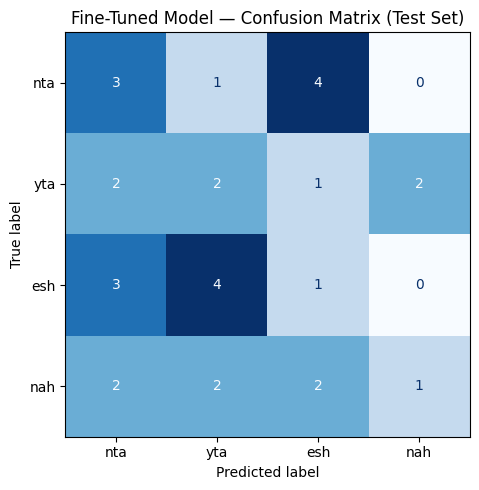

✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README


In [62]:
# Confusion matrix
cm = confusion_matrix(ft_true_ids, ft_pred_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README")

In [63]:
# Print wrong predictions for your error analysis
# Review these carefully — pick 3 to analyze in depth in your README.

wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(ft_true_ids)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")
    print()

Wrong predictions: 23 / 30

--- #1 ---
Text:      AITA my studio kicked me out
Hi all. This is a bit long but I’m looking for advice on how to handle a situation with my studio.
I’m 2 months into dancing, and have never danced before. I absolutely lo...
True:      nta
Predicted: esh  (confidence: 0.29)

--- #2 ---
Text:      AITAH for causing my family to cancel our beach trip because I didn’t want to go?
A few days ago, my dad asked me if I wanted to go to the beach the upcoming Friday since it was a holiday. I told him ...
True:      esh
Predicted: yta  (confidence: 0.37)

--- #3 ---
Text:      AITA for telling my mom that her nagging is not the reason my sister performed well in school?
I (22F) and my Mom (50s) had an argument during a call that stemmed from talking about my little sister (...
True:      nah
Predicted: esh  (confidence: 0.38)

--- #4 ---
Text:      AITAH for needing a very small snack?
Hey folks, I am in a sticky situation for having a very small snack in my roomies

---
### Sample classifications for your README

Your evaluation report needs a **Sample Classifications** table: 3–5 posts with the predicted label
and its confidence, **including at least one correctly-predicted example** you explain.

The cell above only lists *wrong* predictions, so run this one to get a mix. It prints a ready-to-paste
markdown table — write it into your README as text, not a screenshot.

In [64]:
# Sample classifications table for your README (3-5 rows, correct + incorrect).
# Adjust the two counts if you want a different mix.

N_CORRECT, N_WRONG = 3, 2

correct_positions = np.where(ft_pred_ids == ft_true_ids)[0]
wrong_positions   = np.where(ft_pred_ids != ft_true_ids)[0]

if len(correct_positions) == 0:
    print("No correct predictions on the test set - check your label map and training run.")

sample = list(correct_positions[:N_CORRECT]) + list(wrong_positions[:N_WRONG])

print("| Post (truncated) | True label | Predicted | Confidence | Correct? |")
print("|---|---|---|---|---|")
for idx in sample:
    text = str(test_df.iloc[idx]["text"]).replace("|", "\\|").replace("\n", " ")
    if len(text) > 90:
        text = text[:90] + "..."
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    mark = "yes" if pred_label == true_label else "no"
    print(f"| {text} | {true_label} | {pred_label} | {confidence:.2f} | {mark} |")

print()
print("Paste this table into your README under 'Sample Classifications'.")
print("For at least one correct row, add a sentence on why that prediction is reasonable.")

| Post (truncated) | True label | Predicted | Confidence | Correct? |
|---|---|---|---|---|
| AITA For Keeping my Roommate from Going Homeless and Expecting They Would Automatically Un... | nta | nta | 0.33 | yes |
| AITAH for saying what I did to my niece? My niece (28) and I (37) are really close. We’ve ... | nta | nta | 0.31 | yes |
| AITA for not having my brother say goodbye to our mum Context; my mum (45f) was recently d... | nta | nta | 0.33 | yes |
| AITA my studio kicked me out Hi all. This is a bit long but I’m looking for advice on how ... | nta | esh | 0.29 | no |
| AITAH for causing my family to cancel our beach trip because I didn’t want to go? A few da... | esh | yta | 0.37 | no |

Paste this table into your README under 'Sample Classifications'.
For at least one correct row, add a sentence on why that prediction is reasonable.


---
## Section 5: Baseline Classifier (Groq)

Runs your zero-shot baseline using `meta-llama/llama-4-scout-17b-16e-instruct`.  
You need to write the classification prompt using your label definitions.

In [35]:
from groq import Groq

# ── TODO: Add your Groq API key ───────────────────────────────────────────
# Recommended: use Colab Secrets so your key is never visible in the notebook.
#   1. Click the 🔑 icon in the left sidebar ("Secrets")
#   2. Add a secret named GROQ_API_KEY with your key as the value
#   3. Enable notebook access for the secret
#
# Then uncomment Option A below (and delete Option B).
#
# Option A — Colab Secrets (recommended):
from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")
#
# Option B — paste directly (do not commit to GitHub):
#GROQ_API_KEY = "your_groq_api_key_here"

assert GROQ_API_KEY, (
    "GROQ_API_KEY not set — add it in the Colab Secrets panel (\U0001f511, left "
    "sidebar) and enable notebook access for this notebook, or use Option B above."
)

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")

✅ Groq client initialized


In [38]:
# ── TODO: Write your classification prompt ────────────────────────────────
# Your prompt should:
#   1. Name your community and task
#   2. Define each label in plain language (copy from your planning.md)
#   3. Give one example post per label
#   4. Tell the model to output ONLY the label name — nothing else
#
# The model's response must match one of your label strings exactly,
# or the classify_with_groq() function below will mark it as unparseable.
#
# ─────────────────────────────────────────────────────────────────────────
# REPLACE the placeholders below with your actual prompt. As written, this
# skeleton will NOT classify correctly — you must fill it in.

SYSTEM_PROMPT = """
You are a classifier for r/AmItheAsshole (and its sibling r/AITAH), a Reddit community where people describe an interpersonal conflict they were involved in and ask the community to judge who was in the wrong.

Your task: read one post and predict THE VERDICT THE COMMUNITY WOULD REACH — not your own moral opinion. You are modelling how a crowd of Reddit commenters would vote, including their tendencies: they side with clear, sympathetic narrators, they forgive blunt honesty when the substance is right, and they punish authors whose own account reveals them as unreasonable.

Every post is judged on two independent questions:
  1. Is the AUTHOR in the wrong?
  2. Is the OTHER PARTY in the wrong?

The four labels are the four answers:

yta — "You're the A-Hole." The author is in the wrong and the other person or people are not. If the situation hasn't happened yet, the action the author plans to take would make them in the wrong.

nta — "Not the A-Hole." The author is not in the wrong and the other person or people are.

esh — "Everyone Sucks Here." Both the author and the other party are in the wrong, and each did something wrong that stands on its own rather than being a reaction to the other.

nah — "No A-Holes Here." Nobody described is in the wrong. The conflict comes from a genuine clash of needs, expectations, or information, where every party behaved reasonably given what they knew.

WHAT COUNTS AS BEING IN THE WRONG

A party is in the wrong only if they DID one of these:
- demanded, forbade, or issued an ultimatum (not merely asked or objected)
- insulted or name-called — attacked the person, not the position
- retaliated, imposing a consequence beyond simply declining to participate
- deceived, or concealed something that disadvantaged the other party
- withdrew normal relations as punishment (silent treatment, stonewalling, punitive exclusion)
- broke a real obligation — a promise, a duty of care, a contract

These do NOT make someone in the wrong: being upset, saying they are upset even sharply, crying, being mistaken about the facts, declining a request, or being disappointed or inconvenienced.

DECIDING RULES, in priority order:
1. If the other party only expressed hurt and never did anything from the list above, the answer is nah — not nta.
2. If the other party's bad behaviour was a proportionate reaction to something the author did, the other party is not independently in the wrong, so the answer is yta — not esh. But deliberately delivering that reaction in front of an uninvolved audience is its own wrong, unless what they were reacting to was itself public.
3. Hypothetical "WIBTA" posts are judged on the plan as described, using the same list. A post being hypothetical is NOT by itself a reason to answer nah.
4. If the author is right on the substance, blunt or clumsy delivery alone does not make it esh. It becomes esh only if the author did something separately wrong, such as concealment or public humiliation.
5. Where a post is conspicuously silent about something important, read the silence unfavourably to the author.

EXAMPLES

Post: "I told my sister her wedding dress looked cheap. She'd asked what I thought and I decided to be honest. She started crying and left the room. Now my whole family says I ruined her day. I don't see why everyone's upset — she asked for my opinion and I gave it."
Answer: yta

Post: "My coworker borrowed my laptop charger and never returned it. After three weeks of reminders he told me to stop being petty about a ten dollar cable, then blocked me on Slack. I raised it with our manager. He says I escalated something trivial."
Answer: nta

Post: "My brother borrowed $500 and didn't pay it back for a year. At our mother's birthday dinner I brought it up in front of everyone and called him a freeloader. He threw his drink at me and walked out. Mum's night was ruined."
Answer: esh

Post: "I turned down a promotion because it meant relocating and my partner's family is here. My manager told me she was disappointed and that she'd fought hard to get me the offer. She's been supportive since, but I can tell she's frustrated. I feel guilty about it."
Answer: nah

OUTPUT FORMAT

Respond with exactly one of these four strings and nothing else:
yta
nta
esh
nah

No explanation, no reasoning, no punctuation, no quotation marks, no leading or trailing text. Lowercase only.

Always return one of the four labels. If a post is ambiguous, pick the single most likely one. If a post describes upsetting or sensitive events, still return a label — this is a text classification task, not an endorsement.

"""

print("Prompt length:", len(SYSTEM_PROMPT), "characters")

Prompt length: 4613 characters


In [40]:
def classify_with_groq(text):
    """Classify a single post. Returns a label string or None if unparseable."""
    try:
        response = client.chat.completions.create(
            model="openai/gpt-oss-120b",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify this post:\n\n{text}"},
            ],
            temperature=0,
            max_tokens=1024,
            extra_body={"reasoning_effort": "low"},
        )
        raw = response.choices[0].message.content.strip().lower()
        # Match the model's output to a label. Check longest labels first so a
        # label that is a substring of another (e.g. "recommendation" vs.
        # "strong_recommendation") can't be matched by mistake.
        for label in sorted(LABEL_MAP, key=len, reverse=True):
            if raw == label or label in raw:
                return label
        return None  # model output didn't match any known label
    except Exception as e:
        print(f"API error: {e}")
        return None


# Run baseline on test set
print(f"Running baseline on {len(test_df)} examples...")
print("(May take a few minutes — 0.1s delay between requests to respect free-tier limits)\n")

baseline_preds = []
for i, (_, row) in enumerate(test_df.iterrows()):
    pred = classify_with_groq(row["text"])
    baseline_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(test_df)} complete...")
    time.sleep(0.1)

none_count = baseline_preds.count(None)
if none_count > 0:
    print(f"\n⚠️  {none_count} responses could not be parsed.")
    print("Review your prompt — the model may not be outputting clean label names.")

Running baseline on 30 examples...
(May take a few minutes — 0.1s delay between requests to respect free-tier limits)

  10/30 complete...
  20/30 complete...
  30/30 complete...


In [41]:
# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
         if p is not None]
bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
print(f"🎯 Baseline accuracy: {bl_accuracy:.3f}  "
      f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)")
print()
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, zero_division=0))

🎯 Baseline accuracy: 0.467  (evaluated on 30/30 parseable responses)

Per-class metrics (baseline):
              precision    recall  f1-score   support

         nta       0.42      0.62      0.50         8
         yta       0.57      0.57      0.57         7
         esh       0.50      0.12      0.20         8
         nah       0.44      0.57      0.50         7

    accuracy                           0.47        30
   macro avg       0.48      0.47      0.44        30
weighted avg       0.48      0.47      0.44        30



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.  
Download the output files and commit them to your GitHub repo.

In [65]:
print("=" * 50)
print("RESULTS COMPARISON")
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>8}")
print("-" * 45)
print(f"{'Zero-shot baseline (Groq)':<35} {bl_accuracy:>8.3f}")
print(f"{'Fine-tuned DistilBERT':<35} {ft_accuracy:>8.3f}")
print("-" * 45)
delta = ft_accuracy - bl_accuracy
direction = "improvement" if delta >= 0 else "regression"
print(f"\nFine-tuning {direction}: {abs(delta):.3f}")
print()
print("Use these numbers in your README evaluation report.")

RESULTS COMPARISON
Model                               Accuracy
---------------------------------------------
Zero-shot baseline (Groq)              0.467
Fine-tuned DistilBERT                  0.233
---------------------------------------------

Fine-tuning regression: 0.233

Use these numbers in your README evaluation report.


In [66]:
# Save results JSON — commit to your GitHub repo and reference in README
results = {
    "baseline_accuracy": round(bl_accuracy, 4),
    "finetuned_accuracy": round(ft_accuracy, 4),
    "improvement": round(ft_accuracy - bl_accuracy, 4),
    "test_set_size": len(test_df),
    "label_map": LABEL_MAP,
    "model": MODEL_NAME,
}
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Files ready to download:")
print("   evaluation_results.json  — metrics for your README")
print("   confusion_matrix.png     — include in your README")
print()
print("Download via: Files panel (📁) on the left → right-click → Download")

✅ Files ready to download:
   evaluation_results.json  — metrics for your README
   confusion_matrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download
